# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniakhan123/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

# Research Question

Which content items should be prioritized for review or refresh based on recent changes in search impressions and safe search-performance signals?

This analysis supports a content-prioritization decision: identifying which content items show measurable signs of decline and may deserve review before others. The output is decision-support, not a claim that any single signal causes a change in search performance.


In [2]:
# Connect to the FlyRank warehouse

import os
import getpass
import duckdb
import pandas as pd
import numpy as np

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients":
        f"read_parquet('{REL}/dim_clients.parquet')",

    "dim_content":
        f"read_parquet('{REL}/dim_content.parquet')",

    "fact_daily":
        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",

    "fact_daily_sample":
        f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",

    "fact_query_90d":
        f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

# Basic connection check
for name, src in TABLES.items():
    n = con.sql(f"SELECT COUNT(*) FROM {src}").fetchone()[0]
    print(f"{name:22} {n:>12,} rows")

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


## 2. Data

## Data

This analysis uses the FlyRank internship warehouse release. The daily content-performance table contains 78,835,655 rows covering January 27, 2025 through June 30, 2026. The release also contains 104 clients, 519,606 content items, and a query-level 90-day table with 2,414,248 rows. Of the 104 clients, 67 have GSC data and 51 have GA4 data.

The analysis will use the daily content-performance data and the query-level 90-day signals. The data is pseudonymized, so client and content identifiers are used only for grouping and analysis. We will use the time windows needed to construct past-performance features and a later outcome window, rather than requiring every client to have the same amount of historical data. Records or signals that are unavailable for the required feature window will be excluded from the relevant model.


In [4]:
# Section 2 — Data checks

# Overall date range in the daily performance table
date_range = con.sql(f"""
    SELECT
        MIN(report_date) AS earliest_date,
        MAX(report_date) AS latest_date,
        COUNT(*) AS total_rows
    FROM {TABLES['fact_daily']}
""").df()

print("Daily performance date range:")
display(date_range)


# Client coverage
client_summary = con.sql(f"""
    SELECT
        COUNT(*) AS total_clients,
        COUNT(*) FILTER (WHERE gsc_data_start IS NOT NULL) AS clients_with_gsc,
        COUNT(*) FILTER (WHERE ga4_data_start IS NOT NULL) AS clients_with_ga4
    FROM {TABLES['dim_clients']}
""").df()

print("\nClient coverage:")
display(client_summary)


# Check the main daily table columns we will use
# Check the columns available in the daily performance table

columns = con.sql(f"""
    DESCRIBE SELECT *
    FROM {TABLES['fact_daily']}
    LIMIT 1
""").df()

display(columns)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Daily performance date range:


,earliest_date,latest_date,total_rows
0,2025-01-27,2026-06-30,78835655



Client coverage:


,total_clients,clients_with_gsc,clients_with_ga4
0,104,67,51


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


## 3. Methodology

# Methodology

The analysis treats recent search performance as a decision-support signal for content review. Features are calculated from historical GSC performance before the outcome window. The label is whether a content item experienced a decline of more than 20% in impressions during the following 30-day period compared with the preceding 30-day period.

The main features describe prior search demand and performance, including impressions, clicks, click-through rate, average position, position variability, and the number of days with available GSC data. A simple majority-class prediction is used as the baseline.

To reduce temporal leakage, the feature window ends before the outcome window begins. To test whether the result generalizes beyond individual clients, validation is grouped by client rather than randomly splitting content items from the same client across train and test sets. Content items without enough GSC observations in the required windows are excluded from the model.

The model is intended to rank content for review. It does not establish that any feature causes an impression decline or that refreshing a page will produce a particular search outcome.


In [5]:

ANCHOR_DATE = "2026-05-31"

feature_data = con.sql(f"""
    WITH base AS (
        SELECT
            client_hash_id,
            content_hash_id,
            report_date,
            gsc_impressions,
            gsc_clicks,
            gsc_avg_position,
            gsc_data_available
        FROM {TABLES['fact_daily']}
        WHERE report_date BETWEEN
              DATE '{ANCHOR_DATE}' - INTERVAL 59 DAY
              AND DATE '{ANCHOR_DATE}' + INTERVAL 30 DAY
          AND gsc_data_available = TRUE
    ),

    aggregated AS (
        SELECT
            client_hash_id,
            content_hash_id,

            -- Earlier 30-day period: March 3–April 1
            SUM(
                CASE
                    WHEN report_date <= DATE '{ANCHOR_DATE}' - INTERVAL 30 DAY
                    THEN COALESCE(gsc_impressions, 0)
                    ELSE 0
                END
            ) AS imp_prev30,

            SUM(
                CASE
                    WHEN report_date <= DATE '{ANCHOR_DATE}' - INTERVAL 30 DAY
                    THEN COALESCE(gsc_clicks, 0)
                    ELSE 0
                END
            ) AS clicks_prev30,

            AVG(
                CASE
                    WHEN report_date <= DATE '{ANCHOR_DATE}' - INTERVAL 30 DAY
                    THEN gsc_avg_position
                END
            ) AS position_prev30,

            STDDEV_SAMP(
                CASE
                    WHEN report_date <= DATE '{ANCHOR_DATE}' - INTERVAL 30 DAY
                    THEN gsc_avg_position
                END
            ) AS position_volatility,

            COUNT(
                CASE
                    WHEN report_date <= DATE '{ANCHOR_DATE}' - INTERVAL 30 DAY
                    THEN 1
                END
            ) AS feature_days,

            -- Future 30-day outcome
            SUM(
                CASE
                    WHEN report_date > DATE '{ANCHOR_DATE}'
                    THEN COALESCE(gsc_impressions, 0)
                    ELSE 0
                END
            ) AS imp_future30,

            COUNT(
                CASE
                    WHEN report_date > DATE '{ANCHOR_DATE}'
                    THEN 1
                END
            ) AS outcome_days

        FROM base
        GROUP BY client_hash_id, content_hash_id
    )

    SELECT
        *,
        CASE
            WHEN imp_prev30 > 0
            THEN clicks_prev30 * 1.0 / imp_prev30
            ELSE NULL
        END AS ctr_prev30,

        CASE
            WHEN imp_prev30 > 0
             AND outcome_days >= 25
            THEN
                CASE
                    WHEN imp_future30 < 0.8 * imp_prev30 THEN 1
                    ELSE 0
                END
            ELSE NULL
        END AS is_declining

    FROM aggregated
    WHERE feature_days >= 25
""").df()

print(f"Rows before removing incomplete outcome labels: {len(feature_data):,}")

model_data = feature_data.dropna(subset=["is_declining"]).copy()

print(f"Rows available for modeling: {len(model_data):,}")
print(f"Clients represented: {model_data['client_hash_id'].nunique():,}")
print(f"Decline rate: {model_data['is_declining'].mean():.3f}")

model_data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows before removing incomplete outcome labels: 100,254
Rows available for modeling: 73,461
Clients represented: 37
Decline rate: 0.702


,client_hash_id,content_hash_id,imp_prev30,clicks_prev30,position_prev30,position_volatility,feature_days,imp_future30,outcome_days,ctr_prev30,is_declining
2,client_e547b89c05043229,content_2e296120acb03e93,2253.0,1.0,48.196825,10.968640,30,2346.0,30,0.000444,0
3,client_e547b89c05043229,content_516b7c0e8eec0cef,1685.0,0.0,42.846721,9.232626,30,371.0,30,0.000000,1
4,client_e547b89c05043229,content_38b6c1a9aa29f801,6987.0,3.0,41.264724,13.829391,30,5746.0,30,0.000429,0
5,client_e547b89c05043229,content_2ffd36f2a70be7e3,2171.0,0.0,23.737560,8.778149,30,1051.0,30,0.000000,1
6,client_e547b89c05043229,content_4724385fe790d24a,1366.0,8.0,11.659885,3.862918,30,4771.0,30,0.005857,0


In [6]:
# Section 3 — Client-grouped validation and baseline model

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Features known before the outcome window
feature_cols = [
    "imp_prev30",
    "clicks_prev30",
    "ctr_prev30",
    "position_prev30",
    "position_volatility",
    "feature_days"
]

# Keep only rows with complete model features
model_ready = model_data.dropna(subset=feature_cols).copy()

X = model_ready[feature_cols]
y = model_ready["is_declining"]
groups = model_ready["client_hash_id"]

print(f"Model-ready rows: {len(model_ready):,}")
print(f"Clients: {groups.nunique():,}")
print(f"Decline rate: {y.mean():.3f}")


# ---------------------------------------------------------
# Client-grouped train/test split
# ---------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print(f"\nTraining rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Training clients: {groups_train.nunique():,}")
print(f"Test clients: {groups_test.nunique():,}")


# ---------------------------------------------------------
# Majority-class baseline
# ---------------------------------------------------------

majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)

print("\nBASELINE")
print("Majority class:", majority_class)
print("Baseline accuracy:", round(
    accuracy_score(y_test, baseline_pred), 3
))
print("Baseline balanced accuracy:", round(
    balanced_accuracy_score(y_test, baseline_pred), 3
))
print("Baseline F1:", round(
    f1_score(y_test, baseline_pred, zero_division=0), 3
))


# ---------------------------------------------------------
# Random Forest
# ---------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=250,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]


# ---------------------------------------------------------
# Model metrics
# ---------------------------------------------------------

results = {
    "accuracy": accuracy_score(y_test, pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, zero_division=0),
    "recall": recall_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, prob)
}

print("\nMODEL RESULTS")

for metric, value in results.items():
    print(f"{metric:20s}: {value:.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    pred,
    digits=3,
    zero_division=0
))

Model-ready rows: 73,461
Clients: 37
Decline rate: 0.702

Training rows: 44,491
Test rows: 28,970
Training clients: 27
Test clients: 10

BASELINE
Majority class: 1
Baseline accuracy: 0.747
Baseline balanced accuracy: 0.5
Baseline F1: 0.855

MODEL RESULTS
accuracy            : 0.730
balanced_accuracy   : 0.612
precision           : 0.800
recall              : 0.852
f1                  : 0.825
roc_auc             : 0.683

Classification report:
              precision    recall  f1-score   support

         0.0      0.459     0.371     0.410      7326
         1.0      0.800     0.852     0.825     21644

    accuracy                          0.730     28970
   macro avg      0.630     0.612     0.618     28970
weighted avg      0.714     0.730     0.720     28970



## 4. Results (vs baseline)

# Results

The client-grouped evaluation used 73,461 content-client observations from 37 clients. Twenty-seven clients were used for training and 10 unseen clients were held out for testing. The test set contained 28,970 observations.

The majority-class baseline achieved 74.7% accuracy, 50.0% balanced accuracy, and an F1 score of 0.855. The Random Forest achieved 73.0% accuracy, 61.2% balanced accuracy, 80.0% precision, 85.2% recall, 82.5% F1, and a ROC-AUC of 0.683.

The model therefore did not outperform the majority baseline on raw accuracy or F1. However, its balanced accuracy of 61.2% was higher than the baseline's 50.0%, indicating that the model identified both classes better than a strategy that always predicts decline. The model's ROC-AUC of 0.683 also indicates some ability to distinguish higher-risk observations from lower-risk observations.

These results should be treated as directional decision-support evidence rather than proof of a reliable causal or production-grade prediction system. The main practical value is ranking observations for review, not automatically deciding which content should be changed.


In [7]:
# Section 4 — Honest model vs baseline comparison

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1": f1_score(y_test, baseline_pred, zero_division=0),
    "ROC-AUC": 0.5
}

model_metrics = {
    "Accuracy": results["accuracy"],
    "Balanced Accuracy": results["balanced_accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1": results["f1"],
    "ROC-AUC": results["roc_auc"]
}

comparison = pd.DataFrame({
    "Metric": list(baseline_metrics.keys()),
    "Baseline": list(baseline_metrics.values()),
    "Random Forest": list(model_metrics.values())
})

comparison["Difference"] = (
    comparison["Random Forest"] - comparison["Baseline"]
)

display(
    comparison.style.format({
        "Baseline": "{:.3f}",
        "Random Forest": "{:.3f}",
        "Difference": "{:+.3f}"
    })
)

,Metric,Baseline,Random Forest,Difference
0,Accuracy,0.747,0.730,-0.017
1,Balanced Accuracy,0.500,0.612,+0.112
2,Precision,0.747,0.800,+0.053
3,Recall,1.000,0.852,-0.148
4,F1,0.855,0.825,-0.030
5,ROC-AUC,0.500,0.683,+0.183


## 5. Limitations

# Limitations

This analysis has several limitations. First, the model is evaluated on a relatively small set of 37 clients with 10 clients held out for testing, so the result may not generalize to all clients or future releases.

Second, the outcome is defined as an observed change in impressions. The model does not establish why impressions changed, and the analysis cannot determine whether a content refresh would cause performance to improve.

Third, the 20% decline threshold is an analytical choice rather than a universal definition of content deterioration. Different thresholds or time windows could produce different rankings.

Fourth, some observations are excluded when the required historical or outcome data is incomplete. The remaining observations may therefore differ systematically from excluded content.

Finally, the model should be treated as a prioritization and decision-support tool rather than an automated content decision system. The results are directional and should be combined with human review and additional content context before taking action.


In [8]:
# Section 5 — Validation and coverage summary

limitations_summary = pd.DataFrame({
    "Measure": [
        "Total warehouse clients",
        "Clients with GSC data",
        "Clients represented in model",
        "Training clients",
        "Unseen test clients",
        "Model-ready observations",
        "Test observations",
        "Observed decline rate"
    ],
    "Value": [
        104,
        67,
        model_ready["client_hash_id"].nunique(),
        groups_train.nunique(),
        groups_test.nunique(),
        len(model_ready),
        len(X_test),
        y.mean()
    ]
})

display(
    limitations_summary.style.format({
        "Value": lambda x: f"{x:.3f}" if isinstance(x, float) else f"{int(x):,}"
    })
)

,Measure,Value
0,Total warehouse clients,104.000
1,Clients with GSC data,67.000
2,Clients represented in model,37.000
3,Training clients,27.000
4,Unseen test clients,10.000
5,Model-ready observations,73461.000
6,Test observations,28970.000
7,Observed decline rate,0.702


## 6. Ranked recommendations

# Ranked Recommendations

The action playbook prioritizes content items using the model's estimated risk of future impression decline together with recent search-performance signals. Higher-risk items are candidates for earlier review, while lower-risk items can be monitored rather than immediately changed.

The recommended workflow is:

1. **Prioritize for review** — content with high predicted decline risk and meaningful historical impressions.
2. **Review performance drivers** — examine search demand, clicks, CTR, average position, and position volatility for high-priority items.
3. **Monitor** — retain lower-risk content in routine monitoring rather than applying unnecessary changes.
4. **Protect strong performers** — avoid unnecessary changes to content with strong historical performance unless other evidence indicates a problem.

These recommendations are intended as a ranked review queue. They do not imply that refreshing a page will cause impressions to recover, and each recommendation should be reviewed alongside the actual content and business context.


In [9]:
# Section 6 — Generate ranked content recommendations

# Create a scoring table from the held-out test observations.
# The model probability represents estimated risk of the decline class.

recommendations = model_ready.iloc[test_idx].copy()

recommendations["decline_risk"] = prob

# Normalize historical impressions so that very large pages
# do not automatically dominate the ranking.
recommendations["log_impressions"] = np.log1p(
    recommendations["imp_prev30"]
)

# Create a simple priority score:
# predicted risk × log historical impressions
recommendations["priority_score"] = (
    recommendations["decline_risk"] *
    recommendations["log_impressions"]
)

# Rank highest-priority content first
recommendations = recommendations.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

# Add simple action labels
recommendations["recommended_action"] = np.select(
    [
        recommendations["decline_risk"] >= 0.80,
        recommendations["decline_risk"] >= 0.60
    ],
    [
        "Prioritize for review",
        "Review / monitor"
    ],
    default="Monitor"
)

# Show the top 20 recommendations
top_recommendations = recommendations[
    [
        "client_hash_id",
        "content_hash_id",
        "imp_prev30",
        "clicks_prev30",
        "ctr_prev30",
        "position_prev30",
        "position_volatility",
        "decline_risk",
        "priority_score",
        "recommended_action"
    ]
].head(20)

display(
    top_recommendations.style.format({
        "imp_prev30": "{:,.0f}",
        "clicks_prev30": "{:,.0f}",
        "ctr_prev30": "{:.2%}",
        "position_prev30": "{:.2f}",
        "position_volatility": "{:.2f}",
        "decline_risk": "{:.2%}",
        "priority_score": "{:.2f}"
    })
)

,client_hash_id,content_hash_id,imp_prev30,clicks_prev30,ctr_prev30,position_prev30,position_volatility,decline_risk,priority_score,recommended_action
0,client_73cda7b4e4f265ea,content_036a7b994ba532fa,"112,109",108,0.10%,6.77,0.90,97.20%,11.30,Prioritize for review
1,client_73cda7b4e4f265ea,content_b134852a52367a67,"76,179",75,0.10%,6.83,0.66,99.20%,11.15,Prioritize for review
2,client_73cda7b4e4f265ea,content_c3896781c3e7a1f4,"75,239",74,0.10%,7.41,0.51,98.40%,11.05,Prioritize for review
3,client_73cda7b4e4f265ea,content_e9f2d0579387d3c3,"103,613",59,0.06%,7.03,0.81,94.80%,10.95,Prioritize for review
4,client_73cda7b4e4f265ea,content_23a42776a7009b65,"94,046",0,0.00%,9.41,0.35,94.80%,10.86,Prioritize for review
5,client_73cda7b4e4f265ea,content_249ec5f6a4f95fc8,"76,020",47,0.06%,7.40,0.95,96.40%,10.83,Prioritize for review
6,client_73cda7b4e4f265ea,content_e9856d7d976aa034,"113,958",798,0.70%,1.21,0.11,92.80%,10.81,Prioritize for review
7,client_73cda7b4e4f265ea,content_f43118e089ecc69a,"177,623",184,0.10%,5.88,0.61,89.18%,10.78,Prioritize for review
8,client_73cda7b4e4f265ea,content_02ef096f55ba8a61,"102,404",123,0.12%,6.56,0.57,93.20%,10.75,Prioritize for review
9,client_73cda7b4e4f265ea,content_91d8af19d84c05a6,"70,372",37,0.05%,7.32,0.91,96.00%,10.72,Prioritize for review


In [10]:
# Which features drive the model?

feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance.style.format({
        "Importance": "{:.3f}"
    })
)

,Feature,Importance
0,imp_prev30,0.274
1,position_prev30,0.248
2,position_volatility,0.237
3,ctr_prev30,0.157
4,clicks_prev30,0.057
5,feature_days,0.028


## 7. Artifacts the paper embeds

The paper will embed a small set of reproducible artifacts that summarize the data, model performance, and action priorities. These include the model-versus-baseline comparison, feature importance, the distribution of predicted decline risk, and an anonymized summary of the ranked recommendation queue.

The artifacts are generated directly from the analysis notebook so that the reported results remain tied to the underlying model and validation split.


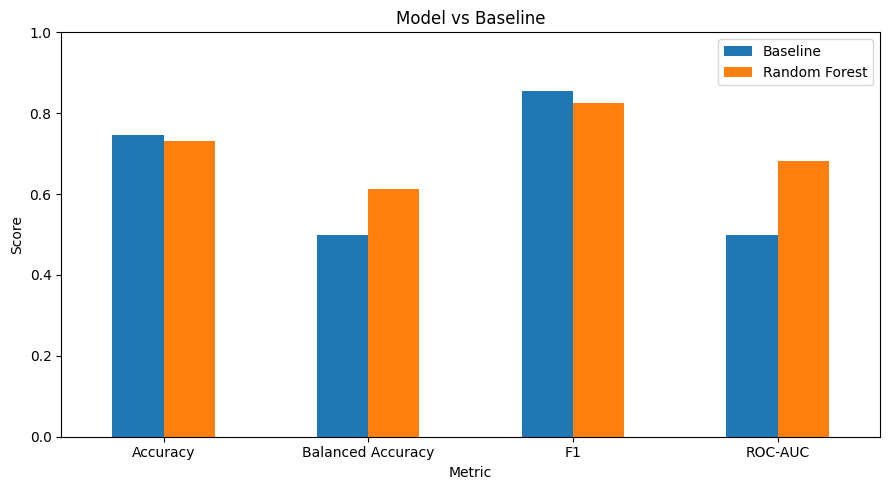

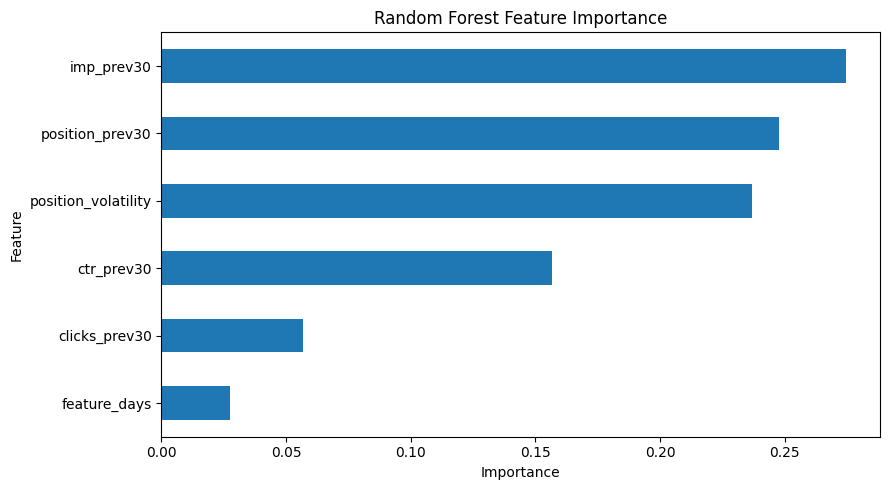

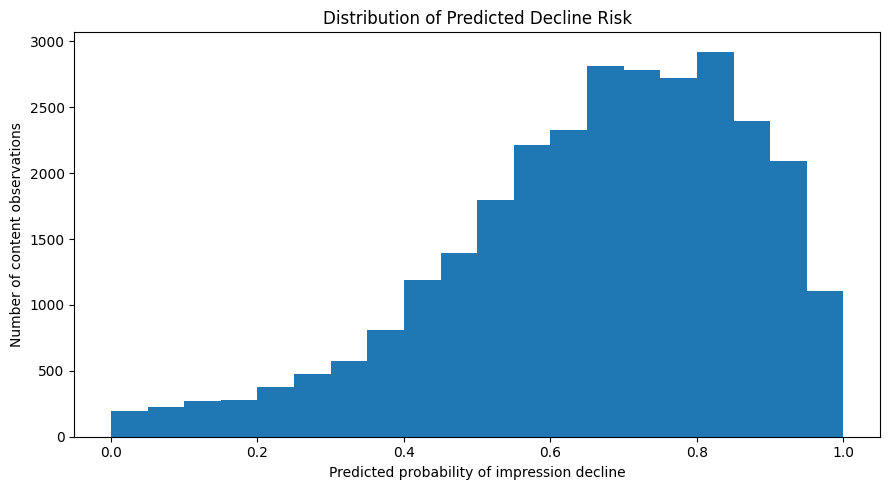

,Recommended action,Content observations
0,Review / monitor,10849
1,Monitor,9597
2,Prioritize for review,8524


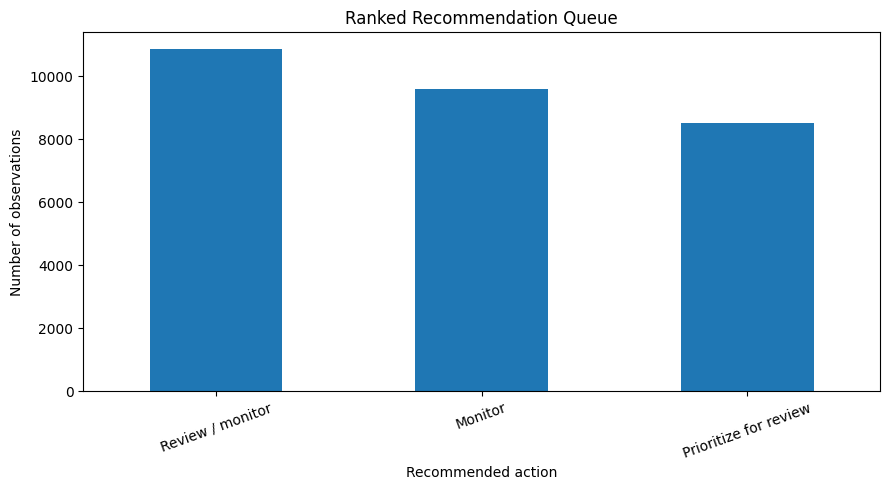

,imp_prev30,clicks_prev30,ctr_prev30,position_prev30,position_volatility,decline_risk,priority_score,recommended_action
0,"112,109",108,0.10%,6.77,0.90,97.20%,11.30,Prioritize for review
1,"76,179",75,0.10%,6.83,0.66,99.20%,11.15,Prioritize for review
2,"75,239",74,0.10%,7.41,0.51,98.40%,11.05,Prioritize for review
3,"103,613",59,0.06%,7.03,0.81,94.80%,10.95,Prioritize for review
4,"94,046",0,0.00%,9.41,0.35,94.80%,10.86,Prioritize for review
5,"76,020",47,0.06%,7.40,0.95,96.40%,10.83,Prioritize for review
6,"113,958",798,0.70%,1.21,0.11,92.80%,10.81,Prioritize for review
7,"177,623",184,0.10%,5.88,0.61,89.18%,10.78,Prioritize for review
8,"102,404",123,0.12%,6.56,0.57,93.20%,10.75,Prioritize for review
9,"70,372",37,0.05%,7.32,0.91,96.00%,10.72,Prioritize for review


In [11]:
# Section 7 — Paper artifacts

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Artifact 1: Model vs baseline
# ---------------------------------------------------------

metrics_to_plot = [
    "Accuracy",
    "Balanced Accuracy",
    "F1",
    "ROC-AUC"
]

artifact_comparison = comparison[
    comparison["Metric"].isin(metrics_to_plot)
].copy()

artifact_comparison = artifact_comparison.set_index("Metric")

artifact_comparison[
    ["Baseline", "Random Forest"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model vs Baseline")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Artifact 2: Feature importance
# ---------------------------------------------------------

feature_importance_plot = feature_importance.sort_values(
    "Importance"
)

feature_importance_plot.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(9, 5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Artifact 3: Predicted decline-risk distribution
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    recommendations["decline_risk"],
    bins=20
)

plt.title("Distribution of Predicted Decline Risk")
plt.xlabel("Predicted probability of impression decline")
plt.ylabel("Number of content observations")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Artifact 4: Recommendation action counts
# ---------------------------------------------------------

action_counts = (
    recommendations["recommended_action"]
    .value_counts()
    .rename_axis("Recommended action")
    .reset_index(name="Content observations")
)

display(action_counts)

action_counts.plot(
    x="Recommended action",
    y="Content observations",
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Ranked Recommendation Queue")
plt.xlabel("Recommended action")
plt.ylabel("Number of observations")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Artifact 5: Top recommendation summary
# ---------------------------------------------------------

top_summary = recommendations.head(20)[
    [
        "imp_prev30",
        "clicks_prev30",
        "ctr_prev30",
        "position_prev30",
        "position_volatility",
        "decline_risk",
        "priority_score",
        "recommended_action"
    ]
].copy()

display(
    top_summary.style.format({
        "imp_prev30": "{:,.0f}",
        "clicks_prev30": "{:,.0f}",
        "ctr_prev30": "{:.2%}",
        "position_prev30": "{:.2f}",
        "position_volatility": "{:.2f}",
        "decline_risk": "{:.2%}",
        "priority_score": "{:.2f}"
    })
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.